In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic_rover_data.csv")

df.head()

,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature,status
0,2026-07-01 00:00:00,43.072474,-89.400668,6.214978,101.499580,30.498199,27.707335,27.063768,29.265164,26.144969,Normal
1,2026-07-01 00:01:00,43.073330,-89.401182,2.904787,101.481014,31.638698,30.454532,24.826910,30.484939,27.499129,Fault
2,2026-07-01 00:02:00,43.073878,-89.401202,30.000000,98.925882,34.718033,29.222000,31.708100,32.937053,18.317683,Normal
3,2026-07-01 00:03:00,43.072368,-89.402706,5.984263,100.572100,36.340124,17.562884,36.368883,29.765023,23.060746,Normal
4,2026-07-01 00:04:00,43.073881,-89.402177,6.773406,102.499250,30.074116,27.359921,33.890405,34.695564,23.604358,Normal


In [2]:
df["battery_drop"] = df["battery_soc"].diff()

In [3]:
df["avg_torque"] = df[
    [
        "wheel_torque_1",
        "wheel_torque_2",
        "wheel_torque_3",
        "wheel_torque_4"
    ]
].mean(axis=1)

In [4]:
df["battery_change_pct"] = df["battery_soc"].pct_change()

In [5]:
df["temp_change"] = df["temperature"].diff()

In [6]:
df["low_battery"] = df["battery_soc"] < 20

In [7]:
df["high_temperature"] = df["temperature"] > 45

In [8]:
threshold = df["avg_torque"].mean() + 3 * df["avg_torque"].std()

df["torque_anomaly"] = df["avg_torque"] > threshold

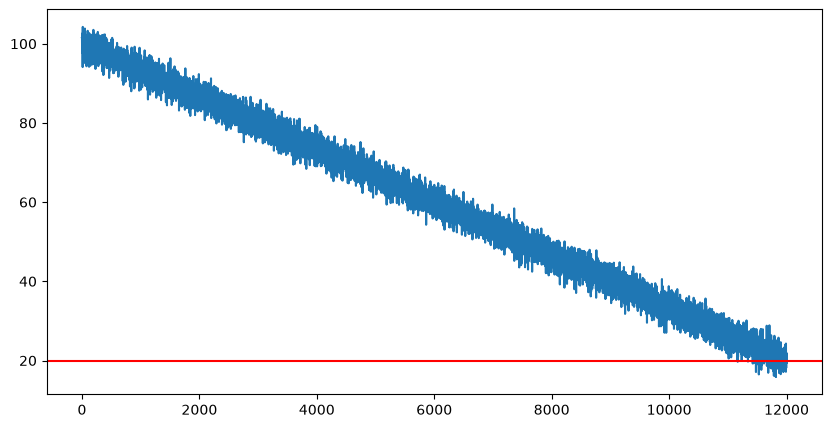

In [11]:
plt.figure(figsize=(10,5))

plt.plot(df["battery_soc"])

plt.axhline(20,color="red")

plt.show()

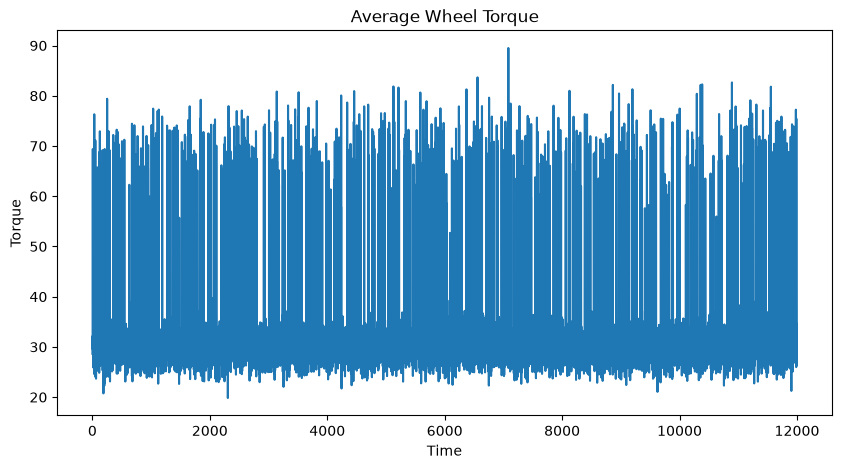

In [16]:
df["avg_torque"] = df[
    [
        "wheel_torque_1",
        "wheel_torque_2",
        "wheel_torque_3",
        "wheel_torque_4"
    ]
].mean(axis=1)

plt.figure(figsize=(10,5))

plt.plot(df["avg_torque"])

plt.title("Average Wheel Torque")

plt.xlabel("Time")

plt.ylabel("Torque")

plt.show()

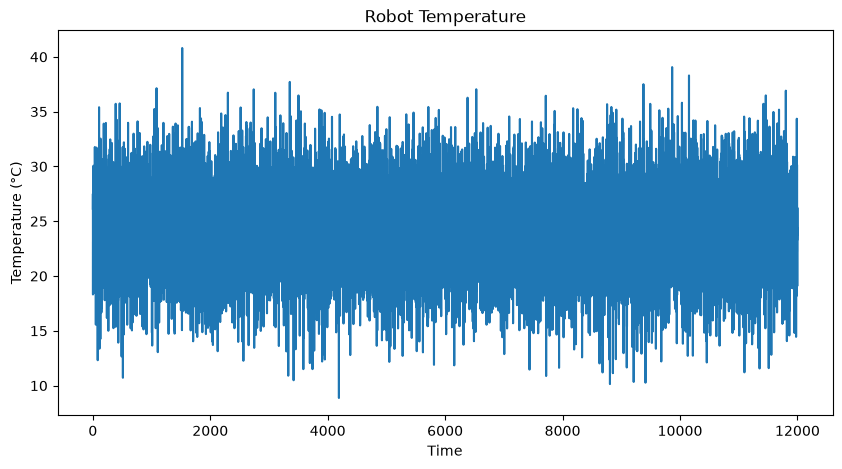

In [17]:
plt.figure(figsize=(10,5))

plt.plot(df["temperature"])

plt.title("Robot Temperature")

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.show()

In [19]:

df["low_battery"] = df["battery_soc"] < 20

df["high_temperature"] = df["temperature"] > 45

threshold = df["avg_torque"].mean() + 3 * df["avg_torque"].std()

df["torque_anomaly"] = df["avg_torque"] > threshold

print("Low battery events:", df["low_battery"].sum())

print("High temperature events:", df["high_temperature"].sum())

print("Torque anomalies:", df["torque_anomaly"].sum())

Low battery events: 126
High temperature events: 0
Torque anomalies: 581


# Week 3 Feature Engineering Summary

## Features Created

- Battery state monitoring
- Average wheel torque
- Temperature monitoring

## Anomaly Detection

- Low battery events
- High temperature events
- Wheel torque anomalies

## Conclusion

The engineered features provide a better understanding of robot operating conditions. Average wheel torque, battery level, and temperature help identify abnormal behaviors and prepare the dataset for future predictive analytics.